# 03 — Exploratory Data Analysis (PySpark + SparkSQL)

## Objective
Understand what drives Customer Lifetime Value (CLV)
in Indian retail banking — using PySpark and SparkSQL
to analyze 16+ million transactions across 50,000 customers.

## The Core EDA Questions
1. How is CLV distributed across customer segments?
2. Which city tiers generate the most revenue?
3. What product combinations predict high CLV?
4. How does transaction behavior differ across CLV buckets?
5. What does monthly spending trajectory look like?
6. Which merchant categories dominate spending?
7. What is the UPI vs traditional channel split?

## New PySpark Concepts in This Notebook
- SparkSQL with CTEs (Common Table Expressions)
- Window functions for running totals and rankings
- .cache() strategy for repeated aggregations
- Joining aggregated results back to customer table
- Visualizing Spark results via .toPandas()

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DateType, IntegerType
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["PATH"]        = r"C:\hadoop\bin;" + os.environ["PATH"]

JAR_PATH = os.path.abspath("../jars/sqlite-jdbc-3.45.1.0.jar")
DB_PATH  = r"D:\some\other\drive\finance_clv.db"
DB_URL   = f"jdbc:sqlite:{DB_PATH}"

LOCAL_TEMP = os.path.abspath("../data/spark_temp")
os.makedirs(LOCAL_TEMP, exist_ok=True)

spark = (
    SparkSession.builder
    .appName("CLV_EDA")
    .master("local[2]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.extraClassPath", JAR_PATH)
    .config("spark.executor.extraClassPath", JAR_PATH)
    .config("spark.local.dir", LOCAL_TEMP)
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

# Load cleaned CSVs back into Spark
# We use CSV here because Parquet write failed on Windows
# In production this would be .read.parquet()
PROCESSED = "../data/processed"

customers = spark.read.option("header","true") \
                .option("inferSchema","true") \
                .csv(f"{PROCESSED}/customers_clean.csv")

products  = spark.read.option("header","true") \
                .option("inferSchema","true") \
                .csv(f"{PROCESSED}/products_clean.csv")

clv       = spark.read.option("header","true") \
                .option("inferSchema","true") \
                .csv(f"{PROCESSED}/clv_labels_clean.csv")

txn       = spark.read.option("header","true") \
                .option("inferSchema","true") \
                .csv(f"{PROCESSED}/transactions_clean.csv")

# Fix date columns after CSV read
# CSV does not preserve DateType — comes back as string
customers = customers.withColumn(
    "account_open_date",
    F.to_date(F.col("account_open_date"), "yyyy-MM-dd")
)
txn = txn.withColumn(
    "txn_date",
    F.to_date(F.col("txn_date"), "yyyy-MM-dd")
).withColumn(
    "txn_year",  F.year("txn_date")
).withColumn(
    "txn_month", F.month("txn_date")
)

# Register all as SQL views
customers.createOrReplaceTempView("customers")
products.createOrReplaceTempView("products")
clv.createOrReplaceTempView("clv_labels")
txn.createOrReplaceTempView("transactions")

print("Data loaded and registered ✅")
print(f"  customers    : {customers.count():>10,}")
print(f"  products     : {products.count():>10,}")
print(f"  clv_labels   : {clv.count():>10,}")
print(f"  transactions : {txn.count():>10,}")
print(f"\nSparkSQL views registered:")
spark.sql("SHOW TABLES").show()

Data loaded and registered ✅
  customers    :     50,000
  products     :    124,865
  clv_labels   :     50,000
  transactions : 16,608,362

SparkSQL views registered:
+---------+------------+-----------+
|namespace|   tableName|isTemporary|
+---------+------------+-----------+
|         |  clv_labels|       true|
|         |   customers|       true|
|         |    products|       true|
|         |transactions|       true|
+---------+------------+-----------+



In [2]:
print("CACHING STRATEGY\n")
print("We cache frequently queried tables.")
print("transactions is 16M rows — cache it once,")
print("query it many times without re-reading CSV.\n")

# Cache the large transaction table
# This is the most important cache decision in this notebook
txn.cache()

# Force materialization — cache fills on first action
_ = txn.count()
print(f"transactions cached ✅  ({txn.count():,} rows in cache)")

# Cache the joined customer+CLV table
# We will use this combination in almost every EDA query
customer_clv = customers.join(
    clv.select("customer_id","clv_next_12months","clv_bucket"),
    on="customer_id",
    how="inner"
)
customer_clv.cache()
_ = customer_clv.count()
customer_clv.createOrReplaceTempView("customer_clv")

print(f"customer_clv cached ✅  ({customer_clv.count():,} rows)")
print(f"\nCached DataFrames:")
print(f"  txn          : is_cached = {txn.is_cached}")
print(f"  customer_clv : is_cached = {customer_clv.is_cached}")

CACHING STRATEGY

We cache frequently queried tables.
transactions is 16M rows — cache it once,
query it many times without re-reading CSV.

transactions cached ✅  (16,608,362 rows in cache)
customer_clv cached ✅  (50,000 rows)

Cached DataFrames:
  txn          : is_cached = True
  customer_clv : is_cached = True


EDA SECTION 1 — CLV DISTRIBUTION

Overall CLV Statistics:
+---------------+--------+----------+---------+-------+--------+--------+---------+
|total_customers|mean_clv|median_clv|std_clv  |min_clv|max_clv |p90_clv |p99_clv  |
+---------------+--------+----------+---------+-------+--------+--------+---------+
|50000          |44628.94|8976.44   |115561.83|0.0    |900000.0|85111.08|681547.48|
+---------------+--------+----------+---------+-------+--------+--------+---------+

CLV Bucket Analysis:
+----------+---------+-------------+---------+---------------+-------------+
|clv_bucket|customers|pct_customers|avg_clv  |total_clv      |pct_total_clv|
+----------+---------+-------------+---------+---------------+-------------+
|very_high |4260     |8.52         |334160.13|1.42352217239E9|63.79        |
|high      |14189    |28.38        |46932.2  |6.6592101185E8 |29.84        |
|medium    |10091    |20.18        |11542.34 |1.164737254E8  |5.22         |
|low       |8948     |17.90        |24

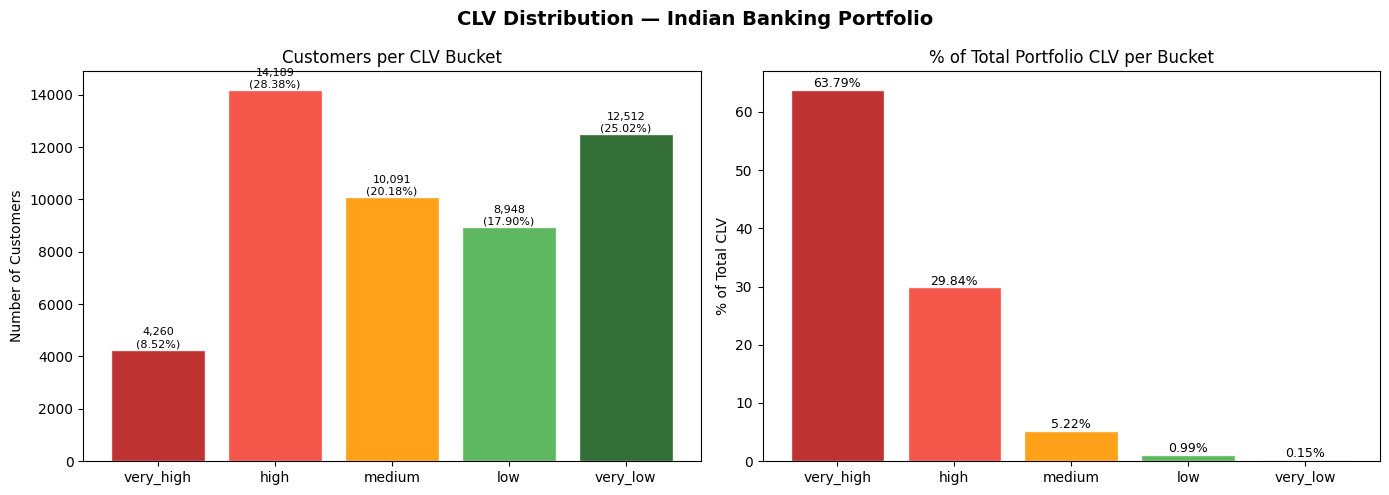

In [3]:
print("EDA SECTION 1 — CLV DISTRIBUTION\n")

# Query 1 — Overall CLV statistics
overall_stats = spark.sql("""
    SELECT
        COUNT(*)                                     AS total_customers,
        ROUND(AVG(clv_next_12months), 2)             AS mean_clv,
        ROUND(percentile_approx(clv_next_12months,
                                0.50, 1000), 2)      AS median_clv,
        ROUND(STDDEV(clv_next_12months), 2)          AS std_clv,
        ROUND(MIN(clv_next_12months), 2)             AS min_clv,
        ROUND(MAX(clv_next_12months), 2)             AS max_clv,
        ROUND(percentile_approx(clv_next_12months,
                                0.90, 1000), 2)      AS p90_clv,
        ROUND(percentile_approx(clv_next_12months,
                                0.99, 1000), 2)      AS p99_clv
    FROM clv_labels
""")

print("Overall CLV Statistics:")
overall_stats.show(truncate=False)

# Query 2 — CLV by bucket with portfolio share
bucket_stats = spark.sql("""
    SELECT
        clv_bucket,
        COUNT(*)                                      AS customers,
        ROUND(COUNT(*) * 100.0 /
              SUM(COUNT(*)) OVER(), 2)                AS pct_customers,
        ROUND(AVG(clv_next_12months), 2)              AS avg_clv,
        ROUND(SUM(clv_next_12months), 2)              AS total_clv,
        ROUND(SUM(clv_next_12months) * 100.0 /
              SUM(SUM(clv_next_12months)) OVER(), 2)  AS pct_total_clv
    FROM clv_labels
    GROUP BY clv_bucket
    ORDER BY avg_clv DESC
""")

print("CLV Bucket Analysis:")
bucket_stats.show(truncate=False)

# Visualize
bucket_pd = bucket_stats.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CLV Distribution — Indian Banking Portfolio",
             fontsize=14, fontweight="bold")

# Customer count by bucket
colors = ["#B71C1C","#F44336","#FF9800","#4CAF50","#1B5E20"]
axes[0].bar(bucket_pd["clv_bucket"], bucket_pd["customers"],
            color=colors, edgecolor="white", alpha=0.9)
axes[0].set_title("Customers per CLV Bucket")
axes[0].set_ylabel("Number of Customers")
for i, v in enumerate(bucket_pd["customers"]):
    axes[0].text(i, v + 100,
                 f"{v:,}\n({bucket_pd['pct_customers'].iloc[i]}%)",
                 ha="center", fontsize=8)

# Portfolio CLV share
axes[1].bar(bucket_pd["clv_bucket"], bucket_pd["pct_total_clv"],
            color=colors, edgecolor="white", alpha=0.9)
axes[1].set_title("% of Total Portfolio CLV per Bucket")
axes[1].set_ylabel("% of Total CLV")
for i, v in enumerate(bucket_pd["pct_total_clv"]):
    axes[1].text(i, v + 0.5, f"{v}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/eda_01_clv_distribution.png",
            dpi=130, bbox_inches="tight")
plt.show()

EDA SECTION 2 — CLV BY SEGMENT AND CITY TIER

CLV by Customer Segment:
+---------------+---------+----------+---------+---------------+-----------------+-------------------+
|segment        |customers|avg_income|avg_clv  |total_clv      |clv_to_income_pct|portfolio_share_pct|
+---------------+---------+----------+---------+---------------+-----------------+-------------------+
|hni            |2451     |1931457.0 |459037.47|1.12510083013E9|23.77            |50.42              |
|salaried_senior|4956     |330297.0  |76329.36 |3.7828831139E8 |23.11            |16.95              |
|self_employed  |7516     |180671.0  |35807.93 |2.6913243283E8 |19.82            |12.06              |
|salaried_mid   |14080    |115382.0  |26827.39 |3.7772961165E8 |23.25            |16.93              |
|retired        |2534     |72736.0   |7085.74  |1.795526505E7  |9.74             |0.8                |
|salaried_entry |12451    |45282.0   |4991.48  |6.214892737E7  |11.02            |2.79               |
|s

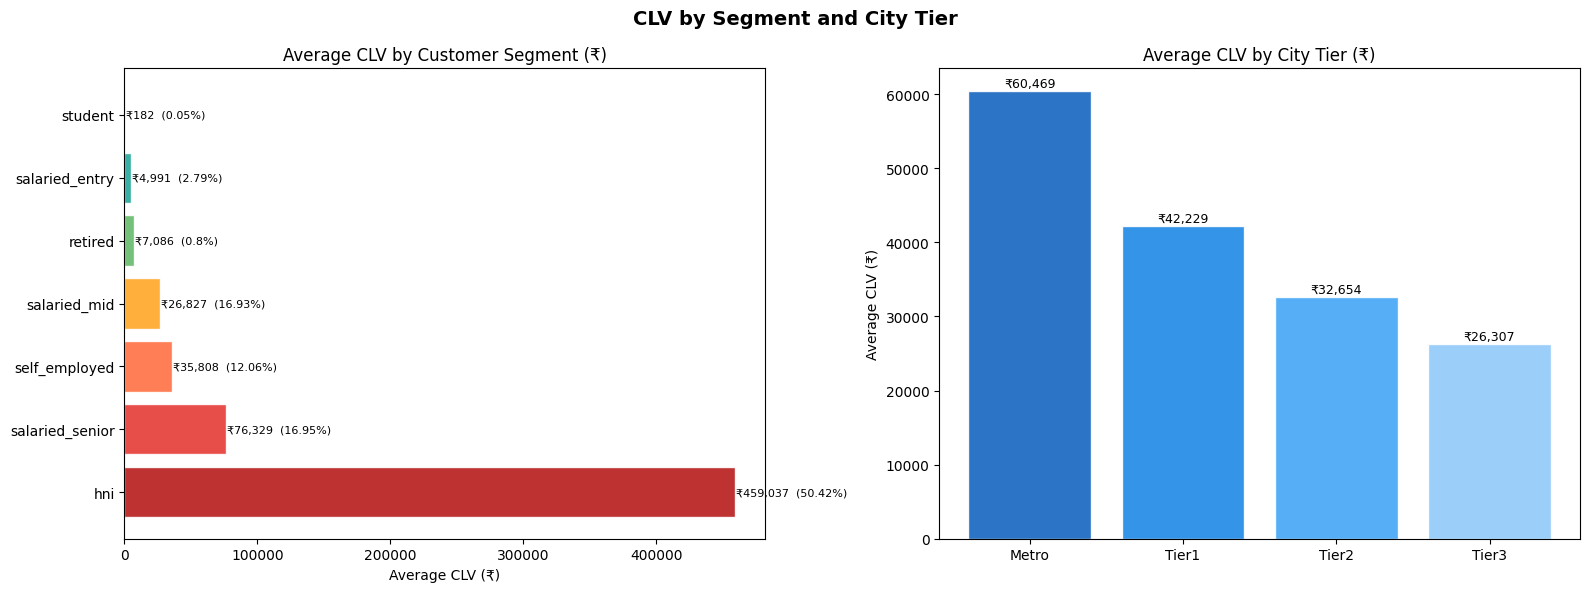

In [4]:
print("EDA SECTION 2 — CLV BY SEGMENT AND CITY TIER\n")

# Query 1 — Segment analysis
segment_clv = spark.sql("""
    SELECT
        c.segment,
        COUNT(*)                                      AS customers,
        ROUND(AVG(c.monthly_income), 0)               AS avg_income,
        ROUND(AVG(l.clv_next_12months), 2)            AS avg_clv,
        ROUND(SUM(l.clv_next_12months), 2)            AS total_clv,
        ROUND(AVG(l.clv_next_12months) /
              AVG(c.monthly_income) * 100, 2)         AS clv_to_income_pct,
        ROUND(SUM(l.clv_next_12months) * 100.0 /
              SUM(SUM(l.clv_next_12months)) OVER(), 2) AS portfolio_share_pct
    FROM customer_clv c
    JOIN clv_labels l ON c.customer_id = l.customer_id
    GROUP BY c.segment
    ORDER BY avg_clv DESC
""")

print("CLV by Customer Segment:")
segment_clv.show(truncate=False)

# Query 2 — City tier analysis
tier_clv = spark.sql("""
    SELECT
        city_tier,
        COUNT(*)                                      AS customers,
        ROUND(AVG(monthly_income), 0)                 AS avg_income,
        ROUND(AVG(clv_next_12months), 2)              AS avg_clv,
        ROUND(SUM(clv_next_12months), 2)              AS total_clv,
        ROUND(MAX(clv_next_12months), 2)              AS max_clv
    FROM customer_clv
    GROUP BY city_tier
    ORDER BY avg_clv DESC
""")

print("CLV by City Tier:")
tier_clv.show(truncate=False)

# Visualize both
seg_pd  = segment_clv.toPandas()
tier_pd = tier_clv.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("CLV by Segment and City Tier",
             fontsize=14, fontweight="bold")

seg_colors = ["#B71C1C","#E53935","#FF7043",
              "#FFA726","#66BB6A","#26A69A","#42A5F5"]
axes[0].barh(seg_pd["segment"], seg_pd["avg_clv"],
             color=seg_colors, edgecolor="white", alpha=0.9)
axes[0].set_title("Average CLV by Customer Segment (₹)")
axes[0].set_xlabel("Average CLV (₹)")
for i, v in enumerate(seg_pd["avg_clv"]):
    axes[0].text(v + 1000, i,
                 f"₹{v:,.0f}  ({seg_pd['portfolio_share_pct'].iloc[i]}%)",
                 va="center", fontsize=8)

tier_colors = ["#1565C0","#1E88E5","#42A5F5","#90CAF9"]
axes[1].bar(tier_pd["city_tier"], tier_pd["avg_clv"],
            color=tier_colors, edgecolor="white", alpha=0.9)
axes[1].set_title("Average CLV by City Tier (₹)")
axes[1].set_ylabel("Average CLV (₹)")
for i, v in enumerate(tier_pd["avg_clv"]):
    axes[1].text(i, v + 500,
                 f"₹{v:,.0f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/eda_02_clv_by_segment_tier.png",
            dpi=130, bbox_inches="tight")
plt.show()

EDA SECTION 3 — TRANSACTION BEHAVIOR BY CLV BUCKET

Transaction Behavior by CLV Bucket:
+----------+----------------+----------+---------------------+--------------+----------------+-------+--------+------------+
|clv_bucket|unique_customers|total_txns|avg_txns_per_customer|avg_txn_amount|avg_annual_spend|upi_pct|rtgs_pct|intl_txn_pct|
+----------+----------------+----------+---------------------+--------------+----------------+-------+--------+------------+
|very_high |4260            |2599026   |610.1                |34287.54      |6652053.6       |48.1   |1.8     |2.0         |
|high      |14189           |5929535   |417.9                |15997.29      |4470880.91      |47.7   |1.8     |1.9         |
|medium    |10091           |3153982   |312.6                |13190.86      |3140249.77      |47.2   |1.8     |1.9         |
|low       |8948            |2566198   |286.8                |12883.44      |2805807.96      |47.0   |1.8     |1.9         |
|very_low  |12512           |2359621 

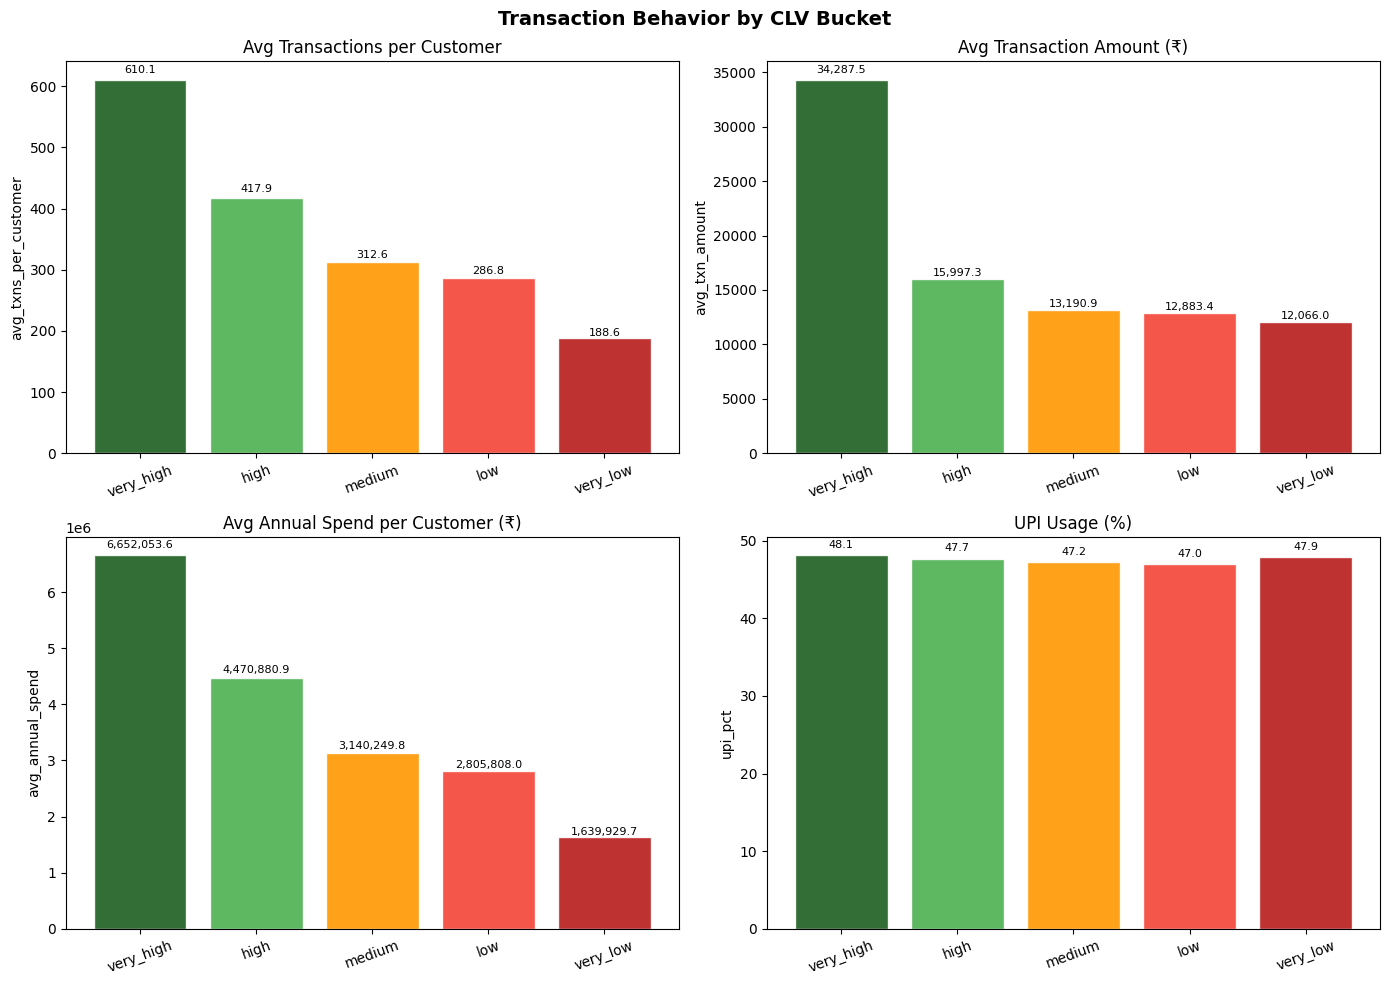

In [5]:
print("EDA SECTION 3 — TRANSACTION BEHAVIOR BY CLV BUCKET\n")

# This is the most important EDA query in the notebook.
# We are asking: do high-CLV customers behave differently
# at the transaction level?

txn_behavior = spark.sql("""
    SELECT
        l.clv_bucket,
        COUNT(DISTINCT t.customer_id)                 AS unique_customers,
        COUNT(t.txn_id)                               AS total_txns,
        ROUND(COUNT(t.txn_id) * 1.0 /
              COUNT(DISTINCT t.customer_id), 1)       AS avg_txns_per_customer,
        ROUND(AVG(t.amount), 2)                       AS avg_txn_amount,
        ROUND(SUM(CASE WHEN t.credit_debit = 'DR'
                       THEN t.amount ELSE 0 END) /
              COUNT(DISTINCT t.customer_id), 2)       AS avg_annual_spend,
        ROUND(SUM(CASE WHEN t.txn_type = 'UPI'
                       THEN 1 ELSE 0 END) * 100.0 /
              COUNT(*), 1)                            AS upi_pct,
        ROUND(SUM(CASE WHEN t.txn_type = 'RTGS'
                       THEN 1 ELSE 0 END) * 100.0 /
              COUNT(*), 1)                            AS rtgs_pct,
        ROUND(SUM(CASE WHEN t.is_international = 1
                       THEN 1 ELSE 0 END) * 100.0 /
              COUNT(*), 1)                            AS intl_txn_pct
    FROM transactions t
    JOIN clv_labels l ON t.customer_id = l.customer_id
    GROUP BY l.clv_bucket
    ORDER BY avg_annual_spend DESC
""")

print("Transaction Behavior by CLV Bucket:")
txn_behavior.show(truncate=False)

# Visualize
beh_pd = txn_behavior.toPandas()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Transaction Behavior by CLV Bucket",
             fontsize=14, fontweight="bold")

bucket_order  = ["very_high","high","medium","low","very_low"]
clv_colors    = ["#1B5E20","#4CAF50","#FF9800","#F44336","#B71C1C"]
beh_pd = beh_pd.set_index("clv_bucket").reindex(
    [b for b in bucket_order if b in beh_pd["clv_bucket"].values
     if "clv_bucket" in beh_pd.columns]
).reset_index() if "clv_bucket" in beh_pd.columns else beh_pd

metrics = [
    ("avg_txns_per_customer", "Avg Transactions per Customer",    axes[0][0]),
    ("avg_txn_amount",        "Avg Transaction Amount (₹)",       axes[0][1]),
    ("avg_annual_spend",      "Avg Annual Spend per Customer (₹)", axes[1][0]),
    ("upi_pct",               "UPI Usage (%)",                    axes[1][1]),
]

for col, title, ax in metrics:
    ax.bar(
        beh_pd["clv_bucket"], beh_pd[col],
        color=clv_colors[:len(beh_pd)],
        edgecolor="white", alpha=0.9
    )
    ax.set_title(title)
    ax.set_ylabel(col)
    ax.tick_params(axis="x", rotation=20)
    for i, v in enumerate(beh_pd[col]):
        ax.text(i, float(v) * 1.02, f"{v:,.1f}",
                ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("../data/processed/eda_03_txn_behavior.png",
            dpi=130, bbox_inches="tight")
plt.show()

EDA SECTION 4 — MONTHLY SPENDING TRENDS

This uses window functions on 16M rows —
the most complex query in this notebook.

monthly_spend rows : 581,938
(~50,000 customers × 12 months = ~600,000 rows)

Platform monthly trends:
+--------+---------+----------------+--------------------+------------------+---------------------+
|txn_year|txn_month|active_customers|platform_total_spend|avg_customer_spend|avg_txns_per_customer|
+--------+---------+----------------+--------------------+------------------+---------------------+
|    2023|        1|           48503|   1.412995467473E10|         291321.25|                 28.6|
|    2023|        2|           48435|   1.405436413615E10|         290169.59|                 28.5|
|    2023|        3|           48562|   1.414671502912E10|         291312.45|                 28.5|
|    2023|        4|           48442|   1.399821553195E10|         288968.57|                 28.5|
|    2023|        5|           48497|   1.411955653519E10|         291142

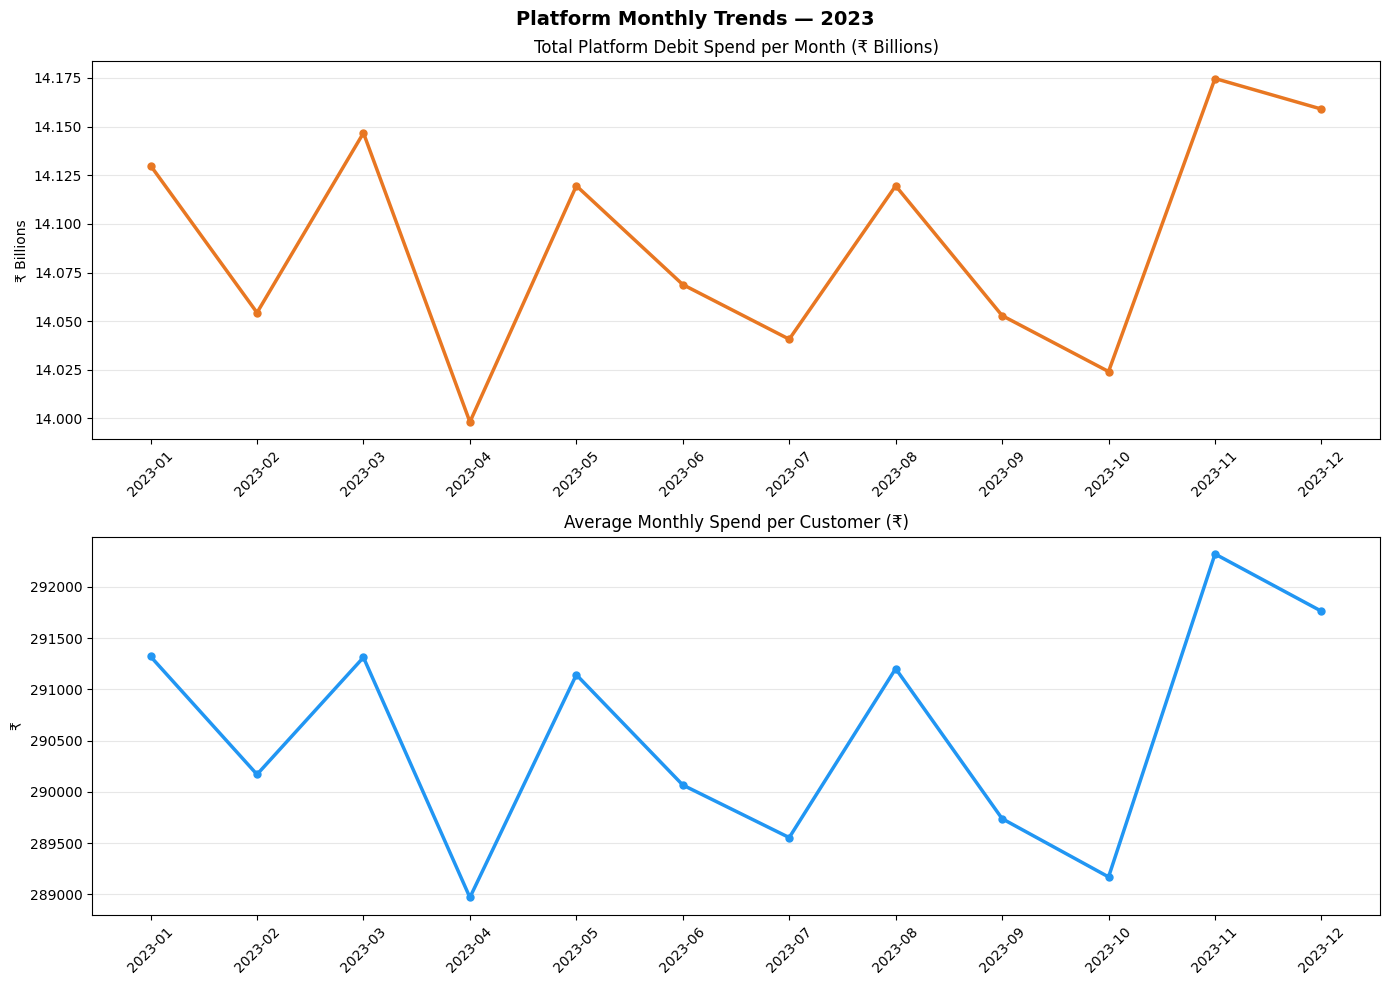

In [6]:
print("EDA SECTION 4 — MONTHLY SPENDING TRENDS\n")
print("This uses window functions on 16M rows —")
print("the most complex query in this notebook.\n")

# Step 1 — Aggregate to monthly level first
monthly_spend = spark.sql("""
    SELECT
        t.customer_id,
        t.txn_year,
        t.txn_month,
        COUNT(t.txn_id)                               AS monthly_txn_count,
        ROUND(SUM(CASE WHEN t.credit_debit = 'DR'
                       THEN t.amount ELSE 0 END), 2)  AS monthly_debit,
        ROUND(SUM(CASE WHEN t.credit_debit = 'CR'
                       THEN t.amount ELSE 0 END), 2)  AS monthly_credit,
        ROUND(AVG(t.amount), 2)                       AS avg_txn_amount,
        COUNT(DISTINCT t.txn_type)                    AS unique_txn_types,
        COUNT(DISTINCT t.merchant_category)           AS unique_categories
    FROM transactions t
    GROUP BY t.customer_id, t.txn_year, t.txn_month
""")

# Register the monthly aggregation as a view
monthly_spend.createOrReplaceTempView("monthly_spend")

# Cache it — we use this in Feature Engineering too
monthly_spend.cache()
_ = monthly_spend.count()
print(f"monthly_spend rows : {monthly_spend.count():,}")
print(f"(~50,000 customers × 12 months = ~600,000 rows)\n")

# Step 2 — Add window features on top of monthly aggregation
w_customer = Window.partitionBy("customer_id") \
                   .orderBy("txn_year", "txn_month")

monthly_with_trend = monthly_spend.withColumn(
    "prev_month_debit",
    F.lag("monthly_debit", 1).over(w_customer)
).withColumn(
    "mom_spend_change",
    F.round(
        F.col("monthly_debit") - F.col("prev_month_debit"), 2
    )
).withColumn(
    "cumulative_debit",
    F.sum("monthly_debit").over(
        w_customer.rowsBetween(
            Window.unboundedPreceding, 0
        )
    )
)

monthly_with_trend.createOrReplaceTempView("monthly_trend")

# Step 3 — Overall monthly trend across all customers
platform_monthly = spark.sql("""
    SELECT
        txn_year,
        txn_month,
        COUNT(DISTINCT customer_id)         AS active_customers,
        ROUND(SUM(monthly_debit), 2)        AS platform_total_spend,
        ROUND(AVG(monthly_debit), 2)        AS avg_customer_spend,
        ROUND(AVG(monthly_txn_count), 1)    AS avg_txns_per_customer
    FROM monthly_spend
    GROUP BY txn_year, txn_month
    ORDER BY txn_year, txn_month
""")

print("Platform monthly trends:")
platform_monthly.show(15)

# Visualize monthly trends
trend_pd = platform_monthly.toPandas()
trend_pd["period"] = (
    trend_pd["txn_year"].astype(str) + "-" +
    trend_pd["txn_month"].astype(str).str.zfill(2)
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Platform Monthly Trends — 2023",
             fontsize=14, fontweight="bold")

axes[0].plot(
    trend_pd["period"],
    trend_pd["platform_total_spend"] / 1e9,
    color="#E87722", linewidth=2.5,
    marker="o", markersize=5
)
axes[0].set_title("Total Platform Debit Spend per Month (₹ Billions)")
axes[0].set_ylabel("₹ Billions")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot(
    trend_pd["period"],
    trend_pd["avg_customer_spend"],
    color="#2196F3", linewidth=2.5,
    marker="o", markersize=5
)
axes[1].set_title("Average Monthly Spend per Customer (₹)")
axes[1].set_ylabel("₹")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../data/processed/eda_04_monthly_trends.png",
            dpi=130, bbox_inches="tight")
plt.show()

EDA SECTION 5 — PRODUCT HOLDING PATTERNS

Product Penetration by CLV Bucket:
+----------+-----------------------+---------------+-------------+---------------+------+-------------+-----------------+-------------------------+
|clv_bucket|customers_with_products|credit_card_pct|home_loan_pct|mutual_fund_pct|fd_pct|insurance_pct|avg_product_value|avg_products_per_customer|
+----------+-----------------------+---------------+-------------+---------------+------+-------------+-----------------+-------------------------+
|very_high |4260                   |51.8           |28.9         |45.1           |54.6  |55.3         |1.046952883E7    |3.8819248826291080       |
|high      |14189                  |41.0           |15.5         |33.1           |40.0  |39.3         |1631540.63       |3.1243921347522729       |
|very_low  |12512                  |11.9           |1.7          |4.5            |4.9   |4.2          |808687.33        |1.5179827365728900       |
|medium    |10091                  

TypeError: Image data of dtype object cannot be converted to float

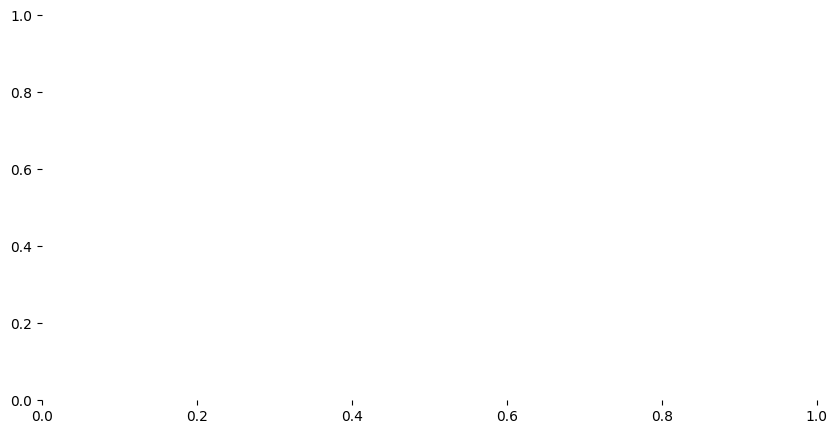

In [ ]:
print("EDA SECTION 5 — PRODUCT HOLDING PATTERNS\n")

# Query 1 — Product penetration by CLV bucket
product_penetration = spark.sql("""
    SELECT
        l.clv_bucket,
        COUNT(DISTINCT p.customer_id)                  AS customers_with_products,
        ROUND(SUM(CASE WHEN p.product_type = 'credit_card'
                       AND p.is_active = true
                       THEN 1 ELSE 0 END) * 100.0 /
              COUNT(DISTINCT p.customer_id), 1)        AS credit_card_pct,
        ROUND(SUM(CASE WHEN p.product_type = 'home_loan'
                       AND p.is_active = true
                       THEN 1 ELSE 0 END) * 100.0 /
              COUNT(DISTINCT p.customer_id), 1)        AS home_loan_pct,
        ROUND(SUM(CASE WHEN p.product_type = 'mutual_fund'
                       AND p.is_active = true
                       THEN 1 ELSE 0 END) * 100.0 /
              COUNT(DISTINCT p.customer_id), 1)        AS mutual_fund_pct,
        ROUND(SUM(CASE WHEN p.product_type = 'fixed_deposit'
                       AND p.is_active = true
                       THEN 1 ELSE 0 END) * 100.0 /
              COUNT(DISTINCT p.customer_id), 1)        AS fd_pct,
        ROUND(SUM(CASE WHEN p.product_type = 'insurance'
                       AND p.is_active = true
                       THEN 1 ELSE 0 END) * 100.0 /
              COUNT(DISTINCT p.customer_id), 1)        AS insurance_pct,
        ROUND(AVG(p.current_value), 2)                 AS avg_product_value,
        COUNT(p.product_id) * 1.0 /
        COUNT(DISTINCT p.customer_id)                  AS avg_products_per_customer
    FROM products p
    JOIN clv_labels l ON p.customer_id = l.customer_id
    GROUP BY l.clv_bucket
    ORDER BY avg_product_value DESC
""")

print("Product Penetration by CLV Bucket:")
product_penetration.show(truncate=False)

# Query 2 — Average product count per customer by segment
product_count = spark.sql("""
    SELECT
        c.segment,
        ROUND(COUNT(p.product_id) * 1.0 /
              COUNT(DISTINCT c.customer_id), 2)        AS avg_products,
        ROUND(AVG(CASE WHEN p.is_active = true
                       THEN p.current_value END), 2)   AS avg_active_value,
        SUM(CASE WHEN p.product_type != 'savings_account'
                 AND p.is_active = true
                 THEN 1 ELSE 0 END) * 1.0 /
        COUNT(DISTINCT c.customer_id)                  AS avg_non_savings_products
    FROM customers c
    JOIN products p ON c.customer_id = p.customer_id
    GROUP BY c.segment
    ORDER BY avg_products DESC
""")

print("Product Count by Segment:")
product_count.show(truncate=False)

# Visualize product penetration heatmap
prod_pd = product_penetration.toPandas()

product_cols = [
    "credit_card_pct","home_loan_pct",
    "mutual_fund_pct","fd_pct","insurance_pct"
]
prod_pd = prod_pd.set_index("clv_bucket")[product_cols].astype(float)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    prod_pd, annot=True, fmt=".1f",
    cmap="YlOrRd", ax=ax,
    linewidths=0.5, cbar_kws={"label": "% of Customers"}
)
ax.set_title(
    "Product Penetration Rate (%) by CLV Bucket\n"
    "(higher = more customers hold that product)",
    fontsize=12
)
ax.set_xlabel("Product Type")
ax.set_ylabel("CLV Bucket")
plt.tight_layout()
plt.savefig("../data/processed/eda_05_product_penetration.png",
            dpi=130, bbox_inches="tight")
plt.show()